# Generative Adversarial Nets — Academic Summary

## Abstract
The paper introduces a framework for estimating generative models through an adversarial process in which two models are trained simultaneously: a generative model $G$ that captures the data distribution, and a discriminative model $D$ that estimates the probability that a sample originated from the training data rather than $G$. Training $G$ maximizes the probability that $D$ makes a mistake, forming a minimax two-player game. In the space of arbitrary functions, a unique solution exists where $G$ recovers the training data distribution and $D$ outputs $\frac{1}{2}$ everywhere. When $G$ and $D$ are multilayer perceptrons, the entire system can be trained end-to-end via backpropagation, without Markov chains or unrolled approximate inference.

## Problems
- Deep generative models had achieved less impact than discriminative models due to the intractability of probabilistic computations in maximum likelihood estimation and related strategies.
- Existing approaches (RBMs, DBMs, DBNs) rely on Markov Chain Monte Carlo (MCMC) methods, which suffer from poor mixing and computational inefficiency, especially as models become more sophisticated.
- Methods such as score matching and noise-contrastive estimation (NCE) require the learned density to be analytically specified up to a normalization constant, and NCE's fixed noise distribution causes learning to slow substantially once an approximate correct distribution is learned.
- Prior generative machines relying on back-propagation (e.g., generative stochastic networks) still require defining Markov chains for sampling.

## Proposed Solutions
- An adversarial framework where $G$ and $D$ compete: $G$ is analogous to counterfeiters trying to produce indistinguishable fake currency, while $D$ acts as a discriminator analogous to police detecting counterfeits.
- $G$ implicitly defines a distribution $p_g$ by transforming a prior noise variable $p_z(z)$ through a differentiable mapping $G(z;\theta_g)$, avoiding any explicit density formulation.
- $D(x;\theta_d)$ outputs a scalar representing the probability that $x$ came from real data rather than $p_g$.
- Both networks are trained jointly using only backpropagation and dropout, with sampling performed via simple forward propagation—eliminating the need for Markov chains or inference networks.

## Purpose
The purpose is to sidestep the intractability issues that limit deep generative modeling by proposing a purely backpropagation-based, adversarially-trained system capable of implicitly learning complex data distributions (e.g., natural images) without explicit likelihood computation or Markov chain sampling.

## Methodology
- **Objective function**: The two-player minimax game is defined as:
$$
\min_{G} \max_{D} V(D,G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$
- **Training procedure (Algorithm 1)**: Alternates between $k$ steps of ascending the discriminator's stochastic gradient and one step of descending the generator's stochastic gradient, keeping $D$ near its optimum while $G$ updates slowly to avoid overfitting the discriminator.
- **Practical objective for $G$**: Since $\log(1-D(G(z)))$ saturates early in training, $G$ is instead trained to maximize $\log D(G(z))$, providing stronger early gradients while preserving the same fixed point.
- **Theoretical analysis**:
  - Proposition 1 derives the optimal discriminator for fixed $G$:
$$
D^*_G(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}
$$
  - Theorem 1 shows the global minimum of the virtual training criterion $C(G)$ is achieved only when $p_g = p_{\text{data}}$, at which point $C(G) = -\log 4$, expressed via the Jensen–Shannon divergence:
$$
C(G) = -\log(4) + 2 \cdot \mathrm{JSD}(p_{\text{data}} \| p_g)
$$
  - Proposition 2 argues convergence of $p_g$ to $p_{\text{data}}$ under sufficient capacity and small updates, leveraging convexity of the supremum function in $p_g$.
- **Architecture**: Generator nets used a mixture of rectifier linear and sigmoid activations; discriminator used maxout activations with dropout during training. Noise was injected only at the generator's input layer.
- **Datasets**: MNIST, Toronto Face Database (TFD), and CIFAR-10.
- **Evaluation metric**: Log-likelihood estimated via Gaussian Parzen window fitting on generated samples, with the Gaussian's $\sigma$ parameter cross-validated.

## Results
| Model | MNIST | TFD |
|---|---|---|
| DBN | $138 \pm 2$ | $1909 \pm 66$ |
| Stacked CAE | $121 \pm 1.6$ | $2110 \pm 50$ |
| Deep GSN | $214 \pm 1.1$ | $1890 \pm 29$ |
| Adversarial nets | $225 \pm 2$ | $2057 \pm 26$ |

- Adversarial nets achieved the highest Parzen window log-likelihood estimate on MNIST and a competitive (second-highest) score on TFD.
- Qualitative sample visualizations (Figures 2–3) on MNIST, TFD, and CIFAR-10 (fully connected and convolutional/deconvolutional variants) demonstrated that generated samples were not memorized copies of training data and were competitive with existing generative model outputs.
- Latent space interpolation between $z$ coordinates produced smooth transitions between generated digit samples, indicating a meaningful, continuous learned manifold.

## Conclusions
- The adversarial framework eliminates the need for Markov chains, approximate inference networks, and intractable partition function estimation, relying solely on backpropagation and dropout.
- Compared to prior generative modeling paradigms (deep directed/undirected graphical models, generative autoencoders), adversarial nets offer computational simplicity and can represent sharp or degenerate distributions without requiring blurry approximations needed for Markov chain mixing.
- Key limitations include the lack of an explicit representation of $p_g(x)$ and the need to carefully synchronize $D$ and $G$ training to avoid failure modes such as the "Helvetica scenario," where $G$ collapses too many $z$ values to the same output.
- The authors outline extensions including conditional generative models $p(x \mid c)$, learned approximate inference networks, semi-supervised learning using discriminator features, and efficiency improvements for coordinating $G$ and $D$ training—directions that substantially shaped subsequent generative modeling research.

# Mathematical and Statistical Content Summary — Generative Adversarial Nets

## 1. The Minimax Value Function
$$
\min_{G} \max_{D} V(D,G) = \mathbb{E}_{x \sim p_{\text{data}}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$
**Explanation**: This is the central equation of the paper. $D$ tries to maximize its ability to correctly label real data ($x$) as real and fake data ($G(z)$) as fake, so it wants $\log D(x)$ and $\log(1-D(G(z)))$ to both be large. $G$ tries to do the opposite — fool $D$ into thinking fake samples are real, so it wants $\log(1-D(G(z)))$ to be small. This sets up a competitive game between the two networks, analogous to a minimax game in game theory.

## 2. The Optimal Discriminator (Proposition 1)
$$
D^*_G(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_g(x)}
$$
**Explanation**: For any fixed generator $G$, this formula gives the best possible discriminator. It says the ideal probability that $D$ assigns to "this is real data" is simply the proportion of real-data density relative to the combined density of real and generated data at point $x$. If $p_{\text{data}}(x) = p_g(x)$ everywhere (generator perfectly matches real data), then $D^*_G(x) = \frac{1}{2}$ — the discriminator can no longer tell real from fake, which is the ideal end state.

**Supporting derivation**: The training objective rewritten as an integral,
$$
V(G,D) = \int_x p_{\text{data}}(x)\log(D(x)) + p_g(x)\log(1-D(x))\,dx
$$
uses the fact that for any two positive constants $a, b$ (not both zero), the function $y \mapsto a\log(y) + b\log(1-y)$ is maximized at $y = \frac{a}{a+b}$. Substituting $a = p_{\text{data}}(x)$ and $b = p_g(x)$ yields the formula above — this is a simple calculus optimization (take the derivative, set to zero) applied pointwise across the data space.

## 3. The Reduced Criterion $C(G)$
$$
C(G) = \mathbb{E}_{x\sim p_{\text{data}}}[\log D^*_G(x)] + \mathbb{E}_{x\sim p_g}[\log(1-D^*_G(x))]
$$
**Explanation**: Once the optimal $D^*_G$ is plugged back in, the two-player game collapses into a single function of $G$ alone. This quantifies how well $G$ is doing once the discriminator has already adapted optimally to it.

## 4. Global Optimum via KL Divergence and Jensen–Shannon Divergence (Theorem 1)
$$
C(G) = -\log(4) + \mathrm{KL}\!\left(p_{\text{data}} \,\Big\|\, \frac{p_{\text{data}}+p_g}{2}\right) + \mathrm{KL}\!\left(p_g \,\Big\|\, \frac{p_{\text{data}}+p_g}{2}\right)
$$
$$
C(G) = -\log(4) + 2\cdot \mathrm{JSD}(p_{\text{data}} \,\|\, p_g)
$$
**Explanation**:
- **KL divergence** ($\mathrm{KL}(P\|Q)$) is a statistical measure of how different one probability distribution $P$ is from a reference distribution $Q$; it is always $\geq 0$ and equals $0$ only when $P = Q$.
- **Jensen–Shannon Divergence (JSD)** is a symmetric, bounded version of KL divergence, built by comparing both $p_{\text{data}}$ and $p_g$ to their average. It is also always $\geq 0$, equal to $0$ only when the two distributions are identical.
- This theorem proves that the training objective $C(G)$ is mathematically equivalent (up to constants) to measuring the JSD between the real data distribution and the generator's distribution. Since JSD is minimized (at zero) only when $p_g = p_{\text{data}}$, this proves the adversarial game has a unique global optimum where the generator perfectly reproduces the true data distribution, achieving $C(G) = -\log 4 \approx -1.386$.

## 5. Convergence Argument (Proposition 2)
**Explanation**: This is a convexity-based argument rather than a single formula. The key statistical/optimization idea used is:
$$
\text{if } f(x) = \sup_{\alpha \in A} f_\alpha(x) \text{ and each } f_\alpha(x) \text{ is convex in } x,\text{ then } \partial f_\beta(x) \in \partial f(x) \text{ where } \beta = \arg\sup_\alpha f_\alpha(x)
$$
This is a standard result from convex analysis: the subgradient of a pointwise supremum of convex functions, evaluated at the maximizing function, is a valid subgradient of the supremum itself. Applied here, $V(G,D)$ is convex in $p_g$, and $\sup_D V(G,D)$ (i.e., using the best discriminator at each step) is also convex in $p_g$ with a unique global minimum (proved in Theorem 1). Since gradient descent on a convex function with sufficiently small steps converges to the global minimum, this supports the claim that $p_g$ converges toward $p_{\text{data}}$ as training proceeds — provided $G$ and $D$ have enough capacity.

## 6. The Training Algorithm's Gradient Updates (Algorithm 1)
**Discriminator ascent step**:
$$
\nabla_{\theta_d} \frac{1}{m} \sum_{i=1}^{m} \left[ \log D\!\left(x^{(i)}\right) + \log\!\left(1 - D\!\left(G\!\left(z^{(i)}\right)\right)\right) \right]
$$
**Generator descent step**:
$$
\nabla_{\theta_g} \frac{1}{m} \sum_{i=1}^{m} \log\!\left(1 - D\!\left(G\!\left(z^{(i)}\right)\right)\right)
$$
**Explanation**: These are stochastic gradient computations over minibatches of size $m$. Instead of computing exact expectations over the full data and noise distributions (which is infeasible), the paper approximates them using minibatch averages — a standard technique in stochastic optimization. $D$'s parameters $\theta_d$ are updated by gradient **ascent** (to increase its accuracy), while $G$'s parameters $\theta_g$ are updated by gradient **descent** (to decrease the discriminator's success rate on fake samples). $D$ is updated $k$ times per single update of $G$, keeping $D$ close to optimal throughout training.

## 7. Alternative (Non-Saturating) Generator Objective
$$
\max_G \; \log D(G(z)) \quad \text{(used in place of minimizing } \log(1-D(G(z)))\text{)}
$$
**Explanation**: Early in training, when $G$ produces poor samples, $D$ can reject them confidently, making $\log(1-D(G(z)))$ close to $\log(1) = 0$ with a near-zero gradient — this is called **saturation**, a common problem in optimization where the loss function's gradient becomes too small to drive learning. Switching to maximizing $\log D(G(z))$ has the same fixed point/optimal solution but produces much larger gradients when $D$ is very confident, allowing $G$ to keep learning.

## 8. Evaluation Metric: Parzen Window (Kernel Density) Log-Likelihood Estimation
**Explanation**: Because $p_g(x)$ has no explicit formula (only samples can be drawn from $G$), the authors cannot compute exact likelihoods. Instead, they use a **Gaussian Parzen window estimator** — a non-parametric statistical technique that builds an approximate probability density by placing a small Gaussian ("bump") of variance $\sigma^2$ around each generated sample, then summing these bumps to estimate the density at any test point. The bandwidth $\sigma$ is chosen via **cross-validation** (testing multiple values and selecting the one generalizing best to a validation set). The **mean log-likelihood** of real test-set examples under this estimated density is then reported, along with the **standard error of the mean** (a measure of the estimate's variability) computed either across data examples (MNIST) or across dataset folds (TFD). This method is noted to have relatively high variance and to perform poorly in high-dimensional spaces, but was the best available tool at the time for comparing models that can generate samples but not compute exact likelihoods.

## Summary of Roles
| Concept | Statistical/Mathematical Role |
|---|---|
| Minimax value function $V(D,G)$ | Formalizes the adversarial two-player game as an optimization problem |
| Optimal discriminator $D^*_G(x)$ | Closed-form pointwise maximization solution (basic calculus) |
| KL Divergence | Measures distributional mismatch; building block for JSD |
| Jensen–Shannon Divergence | Symmetric divergence proving a unique global training optimum |
| Convexity/subgradient argument | Justifies convergence of gradient-based training |
| Minibatch stochastic gradients | Practical approximation of expectations for training via SGD |
| Non-saturating loss trick | Addresses vanishing-gradient problem in early training |
| Parzen window density estimation | Non-parametric technique for evaluating implicit generative models |

# Problems, Limitations, and Proposed Solutions — Generative Adversarial Nets

| # | Key Problem / Research Gap | Limitation on Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Deep generative models have had less impact than discriminative models due to the difficulty of approximating intractable probabilistic computations in maximum likelihood estimation. | Models such as those requiring MLE-based training face computational intractability, restricting the scale and applicability of deep generative approaches. | Introduce an adversarial training procedure that avoids maximum likelihood estimation entirely, learning $G$ implicitly through a discriminative signal rather than explicit density estimation. |
| 2 | Undirected graphical models with latent variables (RBMs, DBMs) require normalization via an intractable partition function. | The partition function and its gradient are intractable for all but trivial cases; approximate estimation requires Markov Chain Monte Carlo (MCMC) methods, which suffer from poor mixing and high computational cost. | Design a framework in which no partition function or normalization constant is required, since $p_g$ is never explicitly represented — only sampled from via $G(z)$. |
| 3 | Deep Belief Networks (DBNs) combine undirected and directed layers, inheriting computational difficulties from both model types. | Hybrid architectures incur the combined intractability issues of both undirected (partition function) and directed (inference) models. | Use a purely feed-forward, fully differentiable architecture (multilayer perceptrons for both $G$ and $D$) that avoids the need for hybrid undirected/directed structures. |
| 4 | Alternative criteria such as score matching and noise-contrastive estimation (NCE) require the model's density to be analytically specified up to a normalization constant. | This requirement is infeasible for deep, multi-layer latent-variable models (e.g., DBNs, DBMs), where a tractable unnormalized density cannot even be derived. Additionally, NCE's fixed noise distribution causes learning to slow drastically once an approximately correct distribution over a subset of variables is learned. | Employ a discriminative training criterion (as in NCE) but replace the fixed noise distribution with a second learnable generative model ($G$) that adapts throughout training, avoiding the slowdown problem. |
| 5 | Existing sample-generating approaches without explicit density functions (e.g., Generative Stochastic Networks, denoising/contractive autoencoders) still depend on defining a parameterized Markov chain for sampling. | Markov chain-based sampling requires multiple sequential steps and can suffer from mixing problems, and piecewise linear units (which aid backpropagation) cause unbounded activations when used in feedback loops. | Eliminate Markov chains entirely: $G$ produces samples via a single forward pass ($x = G(z)$), allowing unrestricted use of piecewise linear units without feedback-loop instability. |
| 6 | Prior generative machines trained via backpropagation (e.g., variational autoencoders, stochastic backpropagation methods) typically require approximate inference networks or variational bounds. | Reliance on inference networks or variational approximations introduces additional architectural and optimization complexity, and may not tightly bound the true likelihood. | Train $G$ and $D$ jointly using only standard backpropagation and dropout, with no inference network needed during training or sample generation. |
| 7 | No tractable method exists to evaluate the exact likelihood $p(x)$ of samples from implicit generative models. | Models that can sample but not compute an explicit likelihood are difficult to compare quantitatively against likelihood-based baselines. | Adopt Parzen-window (Gaussian kernel density) log-likelihood estimation as a proxy evaluation metric, enabling empirical comparison with DBN, Stacked CAE, and Deep GSN baselines on MNIST and TFD. |
| 8 | Balancing the training dynamics between two competing networks is nontrivial; naive training can cause instability. | Without careful coordination, $G$ can be trained "too much" relative to $D$, leading to a failure mode (the "Helvetica scenario") where $G$ maps many distinct $z$ values to the same output $x$, collapsing diversity. | Alternate $k$ discriminator updates per single generator update (Algorithm 1), keeping $D$ near-optimal while $G$ changes slowly; additionally, replace the saturating objective $\log(1-D(G(z)))$ with the non-saturating $\log D(G(z))$ to preserve stronger gradients early in training. |

In [33]:
# ============================================================================
# Educational PyTorch Re-Implementation of:
# "Generative Adversarial Nets" (Goodfellow et al., 2014)
#
# PAPER ANALYSIS (used to drive every design choice below):
#   1. Task type      -> Unsupervised generative modeling. No labels are used
#                         for training. G learns to map noise z -> data space;
#                         D learns to discriminate real data from G's samples.
#   2. Architecture    -> Two MLPs (Sec. 5): G uses "a mixture of rectifier
#                         linear activations and sigmoid activations"; D uses
#                         "maxout activations" with dropout. We implement a
#                         MaxOut layer from scratch (nn.Linear only gives
#                         piecewise-linear units, not the max-over-pieces
#                         nonlinearity the paper specifies).
#   3. Data            -> Paper trains on MNIST / TFD / CIFAR-10: fixed-size
#                         2D images. We use a SYNTHETIC MNIST-like dataset of
#                         small grayscale "blob" images generated from K
#                         Gaussian modes (mimicking K visual digit classes).
#                         This mirrors the paper's fixed-size-image structure
#                         while being fast, deterministic, and license-free.
#                         Mode labels are stored ONLY for post-hoc evaluation
#                         of mode coverage / collapse (Sec. 6, "Helvetica
#                         scenario") -- they are NEVER used during GAN
#                         training, preserving the paper's unsupervised setup.
#   4. Loss            -> Eq. 1 minimax value function V(D,G). G is trained
#                         with the non-saturating heuristic of Sec. 3
#                         (maximize log D(G(z)) instead of minimizing
#                         log(1-D(G(z)))) since it "provides much stronger
#                         gradients early in learning."
#   5. Evaluation      -> Parzen-window (Gaussian kernel density) log-
#                         likelihood estimate (Sec. 5, Table 1), the paper's
#                         actual reported metric -- NOT classification
#                         accuracy.
#   6. "Classes"       -> The K synthetic Gaussian modes are treated as the
#                         paper-appropriate analogue of "classes," directly
#                         supporting the paper's own discussion of mode
#                         collapse. The Discriminator's real-vs-fake decision
#                         is used for the confusion matrix, since D truly is
#                         a binary classifier in this paper (Sec. 3).
# ============================================================================

import math # offer many mathematical operation/function
import io # input-output library in python
from io import BytesIO # is a class that is used to render/display figures/plot/images inline directly inside google colab

import numpy as np # numpy is the ultimate numerical operation library in python

import torch # the core tensor library (torch.tensor, torch autograd)
import torch.nn as nn # nn is short for neural network (nn.Linear, nn.Conv2d, nn.Flatten)
import torch.optim as optim # Adam, SGD, Adadelta ...

from torch.utils.data import Dataset, DataLoader # crucial for creating data pipelines

import torch.nn.functional as F

import matplotlib.pyplot as plt # matplotlib is a plotting library
from matplotlib.gridspec import GridSpec # is a class used for creating a multi-panel custom layout
from IPython.display import Image as IPImage, display # for showing/displyaing directly inline

# ----------------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------------
# The generator starts from random gaussian noise (random latent feature vector)
SEED = 42
torch.manual_seed(SEED) # SEED our pytorch operation (it gets the same results every run)
np.random.seed(SEED) # SEED our numpy operation (it gets the same results every run)

# Device-agnostic selection logic
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [2]:
# ============================================================================
# 1. DATASET — MNIST fetched from Hugging Face Hub (replaces synthetic blobs)
#
# Faithfulness note: the paper's Sec. 5 experiments train directly on MNIST.
# We now load the REAL MNIST dataset via Hugging Face `datasets` instead of
# synthesizing blob images. Images are converted to flattened [0,1] float
# tensors (28x28 -> 784-dim vectors), matching the paper's fixed-size-image,
# label-free (unsupervised) GAN training setup. Digit labels (0-9) are kept
# ONLY for post-hoc evaluation (mode coverage / collapse analysis, Sec. 6),
# exactly mirroring the role synthetic mode labels played before — they are
# NEVER passed to G or D during training.
#
# Dataset size kept modest for a 5-epoch educational run per requirements:
# we subsample 1200 training images and 300 validation images from the full
# HF MNIST splits (60k train / 10k test) using a fixed seed for
# reproducibility, rather than training on the full 60k images.
# ============================================================================

# In this project we are going to use MNIST dataset (handwritten digits)

from datasets import load_dataset # this function used to pull in (fetch) the MNIST dataset
# set the size of the image into 28*28
IMG_SIZE = 28                  # MNIST is 28x28 (was 16x16 for synthetic blobs)

IMG_DIM = IMG_SIZE * IMG_SIZE  # 784 (vectors of size 784)

NUM_MODES = 10                 # digit classes 0-9 (was 8 synthetic Gaussian modes)

N_TRAIN = 5000 # the number of training samples
N_VAL = 600 # the number of testing (validation) samples

print("Downloading MNIST from Hugging Face Hub (datasets library)...")
hf_mnist = load_dataset("ylecun/mnist")  # splits: 'train' (60k), 'test' (10k)

# to get the same training samples/ the same testing smaples
rng = np.random.RandomState(SEED)

# this function is receving three params (hg_split, n_samples, rng)
def _subsample_split(hf_split, n_samples, rng):
    """Pick a fixed random subset of indices from a Hugging Face split."""
    total = len(hf_split) # get the total number of smaples inside HF split

    idx = rng.choice(total, size=n_samples, replace=False)
    return hf_split.select(idx.tolist()) # return the final subset of our images


hf_train_sub = _subsample_split(hf_mnist["train"], N_TRAIN, rng)
hf_val_sub = _subsample_split(hf_mnist["test"], N_VAL, rng)


def _hf_split_to_arrays(hf_split, img_size=IMG_SIZE):
    """
    Convert a Hugging Face MNIST split (PIL images + int labels) into
    flattened float32 [0,1] image arrays and int64 label arrays, matching
    the tensor format the rest of the pipeline (Dataset/Model) expects.
    """
    # a numpy array set to be all zeros of the same shape (64, 784)
    images = np.zeros((len(hf_split), img_size * img_size), dtype=np.float32)
    # a numpy array set to be all zeros (the labels/categories) (int64)
    labels = np.zeros(len(hf_split), dtype=np.int64)

    for i, example in enumerate(hf_split):
        # this line of code fetches a new image and convert into grayscale image resize into 28*28=784
        pil_img = example["image"].convert("L").resize((img_size, img_size))
        # we have to convert our images into numpy arrays + normalize the pixel into the range (0,1)
        arr = np.array(pil_img, dtype=np.float32) / 255.0  # normalize to [0,1]
        # a single channel image into 1D feature vector
        images[i] = arr.reshape(-1)
        labels[i] = int(example["label"])
    return images, labels # return the actual images array + labels array

# we have to adapt our HF MNIST dataset with pytorch internal data pipelies ecosystem
class MNISTDataset(Dataset): # this class is subclassing from torch.nn.Dataset
    """
    Custom Dataset wrapping real MNIST images/labels pulled from Hugging
    Face. Returns (flattened_image[IMG_DIM], digit_label) — digit_label is
    kept ONLY for evaluation (mode/class coverage), never fed to G or D
    during adversarial training, preserving the paper's unsupervised setup.
    """
    # images are actual images arrays (graysclae images) (float32)
    # labels are actaul labels arrays (int64 labels)
    # a dunder method is a speical/magical used to create so sort of operation

    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images) # this will return how many different images do we have inside a HF split

    # create method to return a sample form our dataset (index value)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.images[idx]) # to convert numpy array into pytorch tensor
        y = int(self.labels[idx])
        return x, y # return X, y (as a pair (image, label))


print("Converting Hugging Face MNIST subsets to tensors...")
train_images, train_labels = _hf_split_to_arrays(hf_train_sub)
val_images, val_labels = _hf_split_to_arrays(hf_val_sub)

train_dataset = MNISTDataset(train_images, train_labels)
val_dataset = MNISTDataset(val_images, val_labels)

BATCH_SIZE = 64 # set the Batch_Size Hyperparameter into 64 (every batch contains 64 images + labels)
# Data loader is an iterative sytle datset used to create many several batches
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False) # to save memory

# ---- Sanity check -----------------------------------------------------------
_sample_x, _sample_y = next(iter(train_loader))
print("\n=== Dataset sanity check (real MNIST via Hugging Face) ===")
print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")
print(f"One batch image shape: {_sample_x.shape} (batch, {IMG_DIM} pixels)")
print(f"Pixel value range in batch: [{_sample_x.min():.3f}, {_sample_x.max():.3f}]")
print(f"Digit label ('class') range: [{_sample_y.min().item()}, {_sample_y.max().item()}]")
print(f"Number of digit classes ('classes'): {NUM_MODES}")

# ----------------------------------------------------------------------------
# NOTE on downstream integration (unchanged elsewhere in the notebook):
#   - `assign_to_nearest_mode(...)` (used for mode-coverage Panels E/F) should
#     now be replaced by simply reading each sample's true digit label from
#     `train_dataset.labels` / `val_dataset.labels`, since MNIST already
#     provides ground-truth "classes" — the nearest-centroid heuristic used
#     for synthetic blobs is no longer needed.
#   - `MODE_CENTERS` and `make_blob_image(...)` / `_mode_centers(...)` are no
#     longer used and can be removed.
#   - `Z_DIM`, `Generator`, `Discriminator`, and the training loop (Section 2
#     and 3) are unchanged and work as-is with IMG_DIM=784.
# ----------------------------------------------------------------------------

README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

mnist/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 15.6MB            

mnist/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mnist/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.60MB            

mnist/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Converting Hugging Face MNIST subsets to tensors...

=== Dataset sanity check (real MNIST via Hugging Face) ===
Train size: 5000 | Val size: 600
One batch image shape: torch.Size([64, 784]) (batch, 784 pixels)
Pixel value range in batch: [0.000, 1.000]
Digit label ('class') range: [0, 9]
Number of digit classes ('classes'): 10


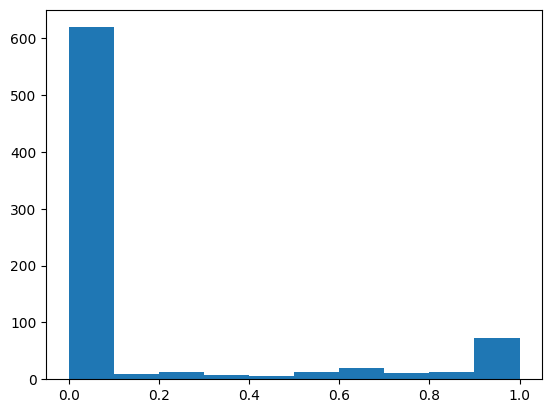

In [31]:
plt.hist(train_dataset[10][0].cpu().numpy());

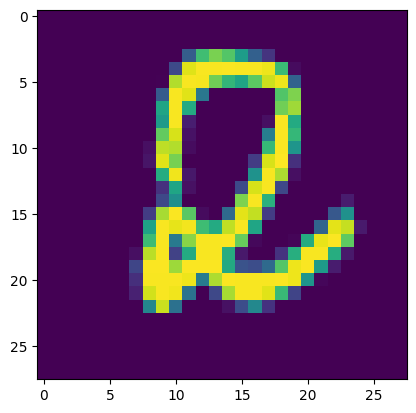

In [30]:
plt.imshow(train_dataset[10][0].cpu().numpy().reshape((28, 28)))

In [3]:
images, labels = next(iter(train_loader))

In [4]:
images, labels

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([9, 6, 8, 2, 9, 2, 0, 0, 9, 5, 0, 0, 5, 9, 2, 2, 7, 2, 1, 3, 4, 4, 8, 6,
         5, 1, 1, 6, 6, 3, 9, 5, 0, 9, 1, 8, 8, 5, 7, 7, 7, 7, 8, 0, 3, 4, 1, 8,
         1, 2, 8, 7, 3, 8, 5, 1, 2, 8, 3, 6, 5, 0, 9, 3]))

In [5]:
images.shape

torch.Size([64, 784])

In [6]:
images[0].min(), images[0].max()

(tensor(0.), tensor(1.))

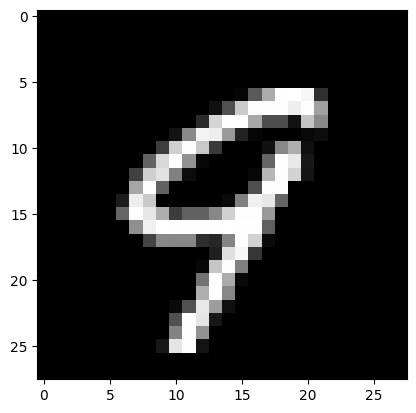

In [7]:
plt.imshow(images[0].view(28, 28), cmap="gray");

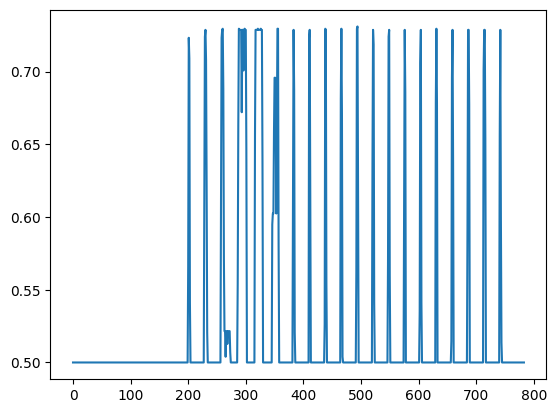

In [37]:
plt.plot(F.sigmoid(train_dataset[0][0]));

In [40]:
F.sigmoid(torch.tensor([-100]))

tensor([0.])

In [9]:
# ============================================================================
# 2. MODEL: Generator (G) and Discriminator (D)
#    Eq. references point back to the paper.
# ============================================================================

# Define the size of the gaussiasn noise vector to set it as 20
# 100 - 512
Z_DIM = 20  # noise prior p_z(z), Sec. 3: "prior on input noise variables p_z(z)"

# The generator is a deep neural network that transforms the noisy vector into structured complex data
# The generator will upsample (reconstruct) our data by transform the noisy vector into our synthetic (authentic) data
# OOP

# 1. Allow automatic differentation
# 2. Allow device transfer (CPU-GPU)
# 3. Save the model into a file alongisde with weights

# this code defines a pytorch implementation of the Generator (G) deep multi-layer perceptron nerual network
class Generator(nn.Module): # pytorch's base class for creating deep neural network in pytorch
    """
    G(z; theta_g): maps noise z to data space (Sec. 3).
    Paper (Sec. 5): "generator nets used a mixture of rectifier linear
    activations and sigmoid activations" -> implemented explicitly below,
    rather than using a single uniform activation throughout.
    Final Sigmoid keeps output pixels in [0,1], matching our image data range.
    """
    # inti will intialize our generator compoenets (fully connected layer, activation function)
    def __init__(self, z_dim=Z_DIM, hidden=128, img_dim=IMG_DIM):
        # z_dim : the size of the random noise vector (20)
        # hidden : the number of hidden units inside fully connected layers
        # img_dim: the final generated image size (784) (MNIST (28, 28))

        # initializing the parent (super) class to make it fully working (weights/biases dicts)
        super().__init__()

        # layer defintions (the layer of the G compoenets)

        # this linear layer will map our random gaussian noise vector into a higher-dimensional space

        self.fc1 = nn.Linear(z_dim, hidden) # plug in weights/bises (z * W + b)
        # introduce non-linearity
        # Rectifier Linear Unit to enable the generator to learn more complex (sophisticated) patterns
        self.relu = nn.ReLU()               # rectifier linear activation (max(0, a))

        # a second fully connected linear layer (Dense layer)
        self.fc2 = nn.Linear(hidden, hidden) # mapping from 128 dim space -> another 128 dim space
        # using a sigmoid activation function (0, 1)
        self.sigmoid_hidden = nn.Sigmoid()  # sigmoid activation (mixture, Sec.5)
        # this linear layer is mapping our hidden space (128 dim space into our final synthetic image)
        self.fc_out = nn.Linear(hidden, img_dim) # creating our image (784)
        # this sigmoid layer will basically restrict (limit) the pixel values into 0, 1
        # sigmoid will squash (squeeze) the pixel values into the range (0, 1)
        self.out_act = nn.Sigmoid()

    # this method will define the forward computation (the computational graph) neural network during training
    def forward(self, z):
        h = self.relu(self.fc1(z)) # h -> hidden reperesenation

        h = self.sigmoid_hidden(self.fc2(h))

        x = self.out_act(self.fc_out(h)) # bound the values between (0, 1)

        return x # x our produced generated synthetic image

# this class implements the maxout activation function layer
# maxout equation is:

# max(X * W + b)

# 1. universal approximator (maxout has the ability to learn any continues convex non-linear function)
# 2. no gradient saturation (unlike sigmoid/tanh which saturate at high values, maxout passing strong gradients)
# 3. flexbile (it has increased capacity + strong expressive power to represent/express strong/complex patterns)

class MaxOutLinear(nn.Module): # pytroch's base class for building neural network

    """
    Maxout unit (Goodfellow et al., 2013, cited as [10] in this very paper).
    Paper (Sec. 5): "the discriminator net used maxout activations."
    For each of `out_dim` output units, compute `num_pieces` linear
    projections and take the elementwise MAX across pieces -- this is a
    piecewise-linear, learnable nonlinearity distinct from ReLU/sigmoid,
    so we implement it from scratch rather than approximating with nn.ReLU.
    """

    def __init__(self, in_dim, out_dim, num_pieces=4):
        # compute K (num_pieces) linear projections and selects the max among those

        super().__init__()

        self.out_dim = out_dim
        self.num_pieces = num_pieces
        # this linear layer is a linear mapping that will create the linear projections of the maxout
        # efficient trick (clever trick) to short cut the linear layer creation
        self.linear = nn.Linear(in_dim, out_dim * num_pieces)

    # this method defines the forward computation (calculation) of the maxout linear layer
    def forward(self, x):
        h = self.linear(x)                       # [B, out_dim * num_pieces]
        # reshaping the flattened output layer
        h = h.view(-1, self.out_dim, self.num_pieces)
        # pytorch max function returns (values, indices)
        out, _ = h.max(dim=2)                     # max over the pieces
        return out

# this class implements a multi-layer perceptron discrimintaor network
class Discriminator(nn.Module): # nn.Module is pytorch's main basic class for creating neural network
    """
    D(x; theta_d): outputs a scalar representing P(x came from real data)
    (Sec. 3). Paper (Sec. 5): maxout activations + dropout in D.
    """

    # discriminator is a deep neural network (supervised binary classification neural network)

    def __init__(self, img_dim=IMG_DIM, hidden=128, num_pieces=4, p_drop=0.5):
        # img_dim: a parameter that defines the flattend image size (784 dim feature vector)
        # hidden: the size of the hidden layer (number of hidden units)
        # num_pieces: defines the number of linear projections of the maxout layer
        # p_drop: the probability of the dropout layer (the prob of droping out some units randomly)
        super().__init__()

        # downsmapling the inputted flattend image vector toward the final classifier output

        self.maxout1 = MaxOutLinear(img_dim, hidden, num_pieces) # the first hidden layer
        # apply a dropout layer with prob=0.5 (50% of the neurons (units) are dropped out randomly)
        self.drop1 = nn.Dropout(p_drop) # reduce the learning power by introducing regulriazation

        # a second fully-conncted dense layer that reduces the size of the input flattened image
        self.maxout2 = MaxOutLinear(hidden, hidden // 2, num_pieces)

        self.drop2 = nn.Dropout(p_drop)
        # this layer maps our hidden feature represenation into a final single scalar value
        self.fc_out = nn.Linear(hidden // 2, 1) # 1 (unbounded value) (logits, -100)
        # final activation function (bound our values into (0, 1))
        self.sigmoid = nn.Sigmoid()  # D(x) in [0,1], Sec. 3

    def forward(self, x):
        h = self.drop1(self.maxout1(x))

        h = self.drop2(self.maxout2(h))
        d = self.sigmoid(self.fc_out(h))
        return d.squeeze(1)  # [B] # remove the training dim

# Instantiatiation instances of this class
G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

n_params_G = sum(p.numel() for p in G.parameters() if p.requires_grad)

n_params_D = sum(p.numel() for p in D.parameters() if p.requires_grad)

TOTAL_PARAMS = n_params_G + n_params_D
print(f"\nGenerator params: {n_params_G} | Discriminator params: {n_params_D} "
      f"| Total: {TOTAL_PARAMS}")


Generator params: 120336 | Discriminator params: 435009 | Total: 555345


In [41]:
G

Generator(
  (fc1): Linear(in_features=20, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (sigmoid_hidden): Sigmoid()
  (fc_out): Linear(in_features=128, out_features=784, bias=True)
  (out_act): Sigmoid()
)

In [46]:
D

Discriminator(
  (maxout1): MaxOutLinear(
    (linear): Linear(in_features=784, out_features=512, bias=True)
  )
  (drop1): Dropout(p=0.5, inplace=False)
  (maxout2): MaxOutLinear(
    (linear): Linear(in_features=128, out_features=256, bias=True)
  )
  (drop2): Dropout(p=0.5, inplace=False)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [45]:
list(iter(D.parameters()))

[Parameter containing:
 tensor([[ 0.0205, -0.0361,  0.0158,  ..., -0.0246, -0.0063,  0.0206],
         [-0.0249, -0.0265,  0.0330,  ...,  0.0326, -0.0125, -0.0313],
         [ 0.0258,  0.0332, -0.0135,  ...,  0.0133, -0.0358,  0.0232],
         ...,
         [-0.0267,  0.0066,  0.0331,  ...,  0.0217,  0.0019, -0.0195],
         [ 0.0259, -0.0337, -0.0096,  ...,  0.0089,  0.0092, -0.0093],
         [-0.0257,  0.0296,  0.0065,  ..., -0.0128, -0.0121, -0.0188]],
        device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([-3.5709e-02,  2.2944e-02,  1.7607e-02, -1.4740e-01,  1.2583e-02,
          1.1272e-02,  5.4647e-02, -1.7009e-02, -3.1842e-03, -1.3666e-03,
          1.5371e-02, -1.9672e-03,  1.3939e-01, -8.4823e-03,  1.0269e-02,
         -2.8734e-02, -4.3307e-02, -1.1363e-01, -1.2122e-01, -1.9523e-02,
         -4.6173e-02, -4.9539e-02, -8.2253e-02, -1.3134e-02, -2.1182e-02,
          1.5322e-03, -3.6073e-02,  1.1372e-01, -7.6844e-03, -1.3276e-02,
         -4.5558e-02, -

Text(0.5, 1.0, 'Real realistic image')

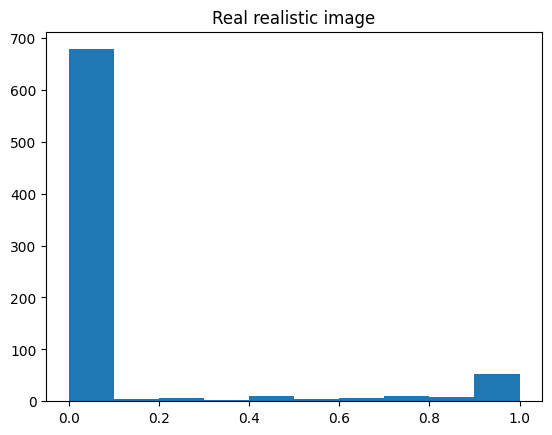

In [76]:
plt.hist(train_dataset[0][0].cpu().numpy());
plt.title("Real realistic image")

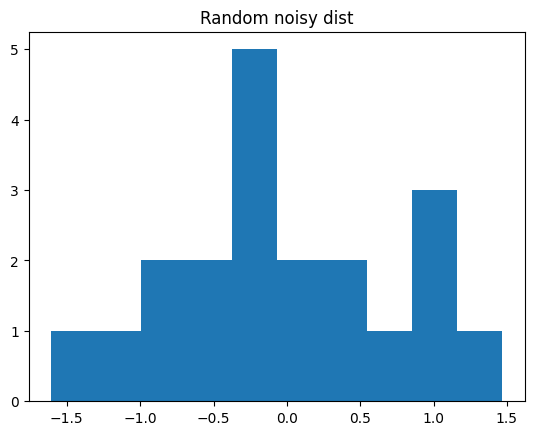

In [75]:
plt.hist(torch.randn(Z_DIM).cpu().numpy());
plt.title("Random noisy dist");

In [10]:
# ============================================================================
# 3. TRAINING (Algorithm 1) — minimax game, Eq. 1
#    d_loss corresponds to maximizing V(D,G) w.r.t. D (we minimize its
#    negative). g_loss uses the NON-SATURATING heuristic from Sec. 3:
#    maximize log D(G(z))  <=>  minimize -log D(G(z)).
#    k = 1 discriminator step per generator step (paper: "We used k = 1,
#    the least expensive option, in our experiments").
#    Optimizer: SGD + momentum, matching "We used momentum in our
#    experiments" (Algorithm 1 caption).
#
#    Dataset update note: this block now runs on real Hugging Face MNIST
#    data (IMG_DIM=784, NUM_MODES=10 digit classes) instead of synthetic
#    Gaussian blobs. The only functional change required is how generated
#    samples are assigned a "mode" for coverage evaluation (Sec. 6,
#    "Helvetica scenario" analogue): instead of measuring distance to fixed
#    synthetic blob centers (`MODE_CENTERS`, now removed), we use a 1-nearest-
#    neighbor lookup against a labeled reference set of REAL MNIST training
#    images. This reuses the true digit labels that MNIST already provides
#    (kept only for this evaluation, never used in the G/D training steps
#    above) as the paper-appropriate analogue of "class."
# ============================================================================
# an epoch is one complete pass over the entire training dataset

# hyper-parameter is a value that machine/deep learning engineer can set

EPOCHS = 300 # one complete pass over the entire train dataset

# learning rate is hyperparameter specifc to the optimizer and NOT the model :)
LR = 0.01 # how aggressive the updates to the wights

# 0.5 momeontum value (adding more mementum)
MOMENTUM = 0.5

# in order to not get into (undefined! problem)
EPS = 1e-8 # a small tiny value that can avoid division by zero

# creating an SGD optimizer
opt_D = optim.SGD(D.parameters(), lr=LR, momentum=MOMENTUM)

# creating an SGD optimizer
opt_G = optim.SGD(G.parameters(), lr=LR, momentum=MOMENTUM)


# in a GANs model we have two deep neural networks:

# 1. Generator (deep neural network model)
#   Role: Creates fake samples from random noise
#   Goal: Fool (trick) the D into thinking (beliving) that its outputs are real

# 2. Discriminator (deep neural network)
#   Role: map our input vector image into a single scalar probability value
#   Goal: Correctly classifing our input samples into real or fake.

# this function computes the log-likelihood of real test images under an implicit gernerative model
# gaussian parzen-window log-likeihood of the real test image (placing a spherical gaussian)

def parzen_log_likelihood(real_x, gen_x, sigma):
    """
    Gaussian Parzen-window log-likelihood estimate (Sec. 5).
    Places a Gaussian kernel of std `sigma` at every generated sample and
    evaluates the resulting mixture density at each real test point.
        log p(x) ~ logsumexp_j [ -||x - g_j||^2 / (2 sigma^2) - (D/2) log(2*pi*sigma^2) ] - log(M)
    """
    D_dim = real_x.shape[1] # obtains the feature dims of the real test images (784)

    # real_x.unsqueeze(1) - expand the dims of the actual real images by inserting a new dim across pos 1
    # input shape: (N, D) -> output shape: (N, 1, D)
    # gen_x.unsqueeze(0) : expand the dims of the generated fake images
    # input shape: (M, D) -> output shape (1, M, D)
    # compute element-wise difference between real test images and produced images

    diff = real_x.unsqueeze(1) - gen_x.unsqueeze(0)          # [N, M, D]
    # takes the square of the differences and return the sum of all those numbers
    sq_dist = (diff ** 2).sum(dim=2)                          # [N, M]

    # compute the log-gaussian equation by this line of code (kernel density estimation (KDE))
    log_kernel = (-0.5 * sq_dist / (sigma ** 2)
                  - 0.5 * D_dim * math.log(2 * math.pi * sigma ** 2))

    # to prevent numerical stability issues (normalizing)
    # log(A/B) = log(A) - log(B)
    log_probs = torch.logsumexp(log_kernel, dim=1) - math.log(gen_x.shape[0])

    return log_probs.mean().item()

# this function chooses the best standard deviation for maximizing the log-likelihood of our KDE

def choose_best_sigma(real_x, gen_x, sigma_grid=(0.05, 0.1, 0.2, 0.35, 0.5)):
    """Cross-validate sigma on a held-out slice, as the paper describes."""

    n = real_x.shape[0] # the total count of available testing images

    cv_split = max(1, n // 2) # caluclate the midpoint index value

    # cv_x: cross-validation samples
    # eval_x: validation held-out testing samples

    cv_x, eval_x = real_x[:cv_split], real_x[cv_split:]


    best_sigma, best_ll = sigma_grid[0], -1e18 # sigma_grid index 0 = 0.05
    # we will run a grid search over our standard deviation values
    for s in sigma_grid:

        ll = parzen_log_likelihood(cv_x, gen_x, s) # compute the mean log-liklihood of the score

        if ll > best_ll: # if it recevies a larger score
            best_ll, best_sigma = ll, s # update the variables with the new computed log-liklihood

    return best_sigma


# ---- Reference set for mode-coverage evaluation (real MNIST version) ------
# Fixed labeled reference bank of real training images, used ONLY to assign
# each generated sample a nearest-neighbor digit label for the mode-coverage
# diagnostic below. Built once, outside the epoch loop, for efficiency.

N_REFERENCE = 300 # fixed sample bank (pool)

# refernces indices choice function
_ref_idx = np.random.RandomState(SEED).choice(len(train_dataset), size=N_REFERENCE, replace=False)
# converting a numpy array into a pytorch tensor and them move that tensor onto our target device
reference_images = torch.from_numpy(train_dataset.images[_ref_idx]).to(DEVICE)     # [N_REFERENCE, IMG_DIM]

# return the labels assoicated with training dataset images
reference_labels = train_dataset.labels[_ref_idx]                                   # [N_REFERENCE]

# we can run 1-NN function algorithm to know which class does the generated fake images belong to

# Model collase is a problem in GANs models that happens when the G figures out that these features
# almost always fool (trick) the D inot thinking or believing that this fake copy looks real
# 1s or 7s (0-1-2-3-4-5-6-7-8-9)
def assign_to_nearest_mode(gen_x, ref_images=reference_images, ref_labels=reference_labels):
    """
    Nearest-neighbor digit-class assignment for mode-coverage evaluation only.
    Replaces the old synthetic-blob centroid heuristic: for each generated
    image, finds the closest real MNIST reference image (L2 distance in
    pixel space) and assigns its true digit label. Used purely for the
    mode-coverage diagnostic (Sec. 6) — never influences G/D training.
    `gen_x` is a torch.Tensor [M, IMG_DIM] on DEVICE.
    """
    # elemetn-wise comparison generated fake images and real ref images
    # how close (how far) the generated images from the actual ground truth label
    diff = gen_x.unsqueeze(1) - ref_images.unsqueeze(0)   # [M, N_REFERENCE, IMG_DIM]
    # square the differences and return the total sum of those numbers along dim 2
    sq_dist = (diff ** 2).sum(dim=2)                       # [M, N_REFERENCE]
    # return th index of the closest possible image
    nearest_idx = torch.argmin(sq_dist, dim=1).cpu().numpy()

    assigned = ref_labels[nearest_idx]

    return assigned # returns the labels (cateogory) of the nearest possible image

# this dict is used so that will containe the values of the metrics
history = {
    "d_loss": [], "g_loss": [],
    "v_value": [], "jsd_estimate": [],
    "train_parzen_ll": [], "val_parzen_ll": [],
    "mode_coverage_per_epoch": [],  # list of arrays [NUM_MODES]
}


# Training Loop
# 1. Forward pass
# 2. Loss calculation (measure how far its prection from real prediction)
# 3. Optimzer zero grad (empty out past space/memory)
# 4. Backpropgate (algorithm to assign blame)
# 5. Optimizer step (move each step further to make it more reasonable/represenative)

fixed_eval_z = torch.randn(300, Z_DIM, device=DEVICE)  # fixed noise for consistent eval across epochs

# EPOCHS  = 5
for epoch in range(1, EPOCHS + 1):
    # set the mode of G and D as training mode

    G.train()
    D.train()


    running_d, running_g, running_v = 0.0, 0.0, 0.0

    n_batches = 0
    # creating a for-loop interation so that to get (obtain) the batches to the training steps
    for real_x, _ in train_loader: # a DataLoader of MNIST images 28X28 -> 1D (784)

        real_x = real_x.to(DEVICE)

        b = real_x.shape[0] # get the total count of the samples inside a batch

        # 1. Generate fake samples
        # 2. Pass our fake generated samples into the D
        # 3. Calculate the D loss
        # 4. Backpropagte the gradients of the params of the D backward
        # 5. Update the D weights/biases

        # ---- (1) Update Discriminator: k=1 step, ascend V(D,G) ----------
        # a contineues random gaussian noise vector
        # b is a batch size
        # Z_DIM the size of the noise vector (20-dim noisy vector)
        z = torch.randn(b, Z_DIM, device=DEVICE)

        # generate a fake (not real) sample (maps that noise vector to the actual synthetic image)
        # it's essential to detach the fake produced samples so that the gradinets do not flow backward to the G

        fake_x = G(z).detach() # REAL IMPORTNANT!

        # performing forward pass on the D by passing two distint forward pass

        d_real = D(real_x) # how real the X is really real
        d_fake = D(fake_x) # how real the fake samples looks real

        # claculate the loss of D

        # Eq. 1 (sample average): V = E[log D(x)] + E[log(1-D(G(z)))]

        v_value = torch.mean(torch.log(d_real + EPS)) + torch.mean(torch.log(1 - d_fake + EPS))
        # the loss is the inverse of the optimization equation
        d_loss = -v_value  # minimize negative V  <=> maximize V w.r.t. D

        # clear the old gradients of the D old steps

        opt_D.zero_grad()

        # compute the gradients of the params with respect to the weights/biases
        d_loss.backward() # compute gradients (derivatives) of the loss function w.r.t the weights

        # use those computed gradients to update the params (weights/baises)
        opt_D.step() # new_theta = old_theta - learning_rate * the_gradients_of_the_loss

        # ---- (2) Update Generator: non-saturating heuristic (Sec. 3) ----
        # sampling new random noise vector (Z1, Z2, Z3)

        z2 = torch.randn(b, Z_DIM, device=DEVICE)

        fake_x2 = G(z2) # a deep gernerator neural network (upsampling, reconstruction)

        d_fake2 = D(fake_x2)

        # Loss calcuation
        # a modern term appraoch to actaully prevent vanishing gradients

        g_loss = -torch.mean(torch.log(d_fake2 + EPS))  # maximize log D(G(z))

        opt_G.zero_grad()
        # compute the gradients of the G with respect to the weights/biases

        g_loss.backward() # compute gradients w.r.t to the weights/biases

        opt_G.step() # theta_new = theta_old - learning_rate * the graidents of the loss function

        # loss accumulation of the metrics so that we do not lose them
        running_d += d_loss.item()
        running_g += g_loss.item()
        running_v += v_value.item()

        n_batches += 1
    # normalizing our metircs into interperatable values
    avg_d = running_d / n_batches
    avg_g = running_g / n_batches
    avg_v = running_v / n_batches

    # Theorem 1 / Eq. 6: C(G) = -log4 + 2*JSD(p_data || p_g). At the optimal
    # D, V ≈ C(G), so we derive an approximate JSD estimate purely for
    # educational visualization of the paper's key theoretical quantity.
    jsd_estimate = max(0.0, (avg_v + math.log(4)) / 2.0)

    history["d_loss"].append(avg_d)
    history["g_loss"].append(avg_g)
    history["v_value"].append(avg_v)
    history["jsd_estimate"].append(jsd_estimate)

    # ---- Evaluation: Parzen-window log-likelihood (Sec. 5, Table 1) -----
    G.eval(); D.eval()
    with torch.no_grad(): # stop the gradient process of tracking
        gen_eval = G(fixed_eval_z)

        train_real_sample = torch.stack([train_dataset[i][0] for i in range(200)]).to(DEVICE)
        val_real_sample = torch.stack([val_dataset[i][0] for i in range(len(val_dataset))]).to(DEVICE)

        sigma = choose_best_sigma(val_real_sample, gen_eval)
        train_ll = parzen_log_likelihood(train_real_sample, gen_eval, sigma)
        val_ll = parzen_log_likelihood(val_real_sample, gen_eval, sigma)

        history["train_parzen_ll"].append(train_ll)
        history["val_parzen_ll"].append(val_ll)

        # ---- Mode coverage (Sec. 6 "Helvetica scenario" analogue) -------
        assigned_modes = assign_to_nearest_mode(gen_eval)
        coverage = np.bincount(assigned_modes, minlength=NUM_MODES) / len(assigned_modes)
        history["mode_coverage_per_epoch"].append(coverage)

    print(f"Epoch {epoch}/{EPOCHS} | D_loss={avg_d:.4f} | G_loss={avg_g:.4f} | "
          f"V={avg_v:.4f} | JSD~{jsd_estimate:.4f} | "
          f"TrainParzenLL={train_ll:.2f} | ValParzenLL={val_ll:.2f} | sigma={sigma}")

Epoch 1/300 | D_loss=0.6370 | G_loss=2.5372 | V=-0.6370 | JSD~0.3747 | TrainParzenLL=-521.52 | ValParzenLL=-521.39 | sigma=0.5
Epoch 2/300 | D_loss=0.0985 | G_loss=4.8989 | V=-0.0985 | JSD~0.6439 | TrainParzenLL=-427.06 | ValParzenLL=-424.92 | sigma=0.35
Epoch 3/300 | D_loss=0.0945 | G_loss=4.6422 | V=-0.0945 | JSD~0.6459 | TrainParzenLL=-281.73 | ValParzenLL=-277.31 | sigma=0.35
Epoch 4/300 | D_loss=0.1380 | G_loss=3.8375 | V=-0.1380 | JSD~0.6241 | TrainParzenLL=-226.36 | ValParzenLL=-221.48 | sigma=0.35
Epoch 5/300 | D_loss=0.1145 | G_loss=3.7224 | V=-0.1145 | JSD~0.6359 | TrainParzenLL=-190.03 | ValParzenLL=-185.74 | sigma=0.35
Epoch 6/300 | D_loss=0.1052 | G_loss=3.6580 | V=-0.1052 | JSD~0.6405 | TrainParzenLL=-160.92 | ValParzenLL=-161.78 | sigma=0.35
Epoch 7/300 | D_loss=0.1002 | G_loss=3.4788 | V=-0.1002 | JSD~0.6430 | TrainParzenLL=-132.93 | ValParzenLL=-139.96 | sigma=0.35
Epoch 8/300 | D_loss=0.1616 | G_loss=2.6566 | V=-0.1616 | JSD~0.6123 | TrainParzenLL=-155.22 | ValParzenL

In [11]:

# ============================================================================
# 4. PREDICTION / QUALITATIVE PIPELINE
#    (a) Generated samples vs. nearest real training example (paper Fig. 2:
#        "Rightmost column shows the nearest training example ... to
#        demonstrate the model has not memorized the training set.")
#    (b) Latent-space interpolation between two z points (paper Fig. 3:
#        "Digits obtained by linearly interpolating between coordinates in
#        z space").
# ============================================================================

G.eval()
with torch.no_grad():
    n_show = 6
    z_show = torch.randn(n_show, Z_DIM, device=DEVICE)
    gen_show = G(z_show).cpu().numpy()

    train_imgs_all = train_dataset.images  # [N, IMG_DIM]
    nearest_neighbors = []
    for g_img in gen_show:
        dists = np.sum((train_imgs_all - g_img[None, :]) ** 2, axis=1)
        nearest_neighbors.append(train_imgs_all[np.argmin(dists)])
    nearest_neighbors = np.stack(nearest_neighbors)

    print("\n=== Qualitative predictions (Generated | Nearest real training example) ===")
    for i in range(n_show):
        print(f"Sample {i+1}: generated image stats "
              f"(mean={gen_show[i].mean():.3f}, max={gen_show[i].max():.3f}) | "
              f"nearest-neighbor distance={np.sum((gen_show[i]-nearest_neighbors[i])**2):.4f}")

    # Latent interpolation (Fig. 3 analogue)
    z_a = torch.randn(1, Z_DIM, device=DEVICE)
    z_b = torch.randn(1, Z_DIM, device=DEVICE)
    n_interp = 8
    alphas = np.linspace(0, 1, n_interp)
    interp_imgs = []
    for a in alphas:
        z_interp = (1 - a) * z_a + a * z_b
        interp_imgs.append(G(z_interp).cpu().numpy().reshape(IMG_SIZE, IMG_SIZE))

# ---- Standard educational plots (pre-dashboard) -----------------------------
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "text.color": "black", "axes.labelcolor": "black",
    "xtick.color": "black", "ytick.color": "black",
    "axes.edgecolor": "black",
})

fig_q, axes_q = plt.subplots(2, n_show, figsize=(3 * n_show, 6), facecolor="white")
for i in range(n_show):
    axes_q[0, i].imshow(gen_show[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray", vmin=0, vmax=1)
    axes_q[0, i].set_title(f"Generated {i+1}", color="black")
    axes_q[0, i].axis("off")
    axes_q[1, i].imshow(nearest_neighbors[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray", vmin=0, vmax=1)
    axes_q[1, i].set_title("Nearest real", color="black")
    axes_q[1, i].axis("off")
fig_q.suptitle("Generated samples vs. nearest real training example (cf. Fig. 2)", color="black")
plt.close(fig_q)

fig_interp, axes_interp = plt.subplots(1, n_interp, figsize=(2 * n_interp, 2.2), facecolor="white")
for i, img in enumerate(interp_imgs):
    axes_interp[i].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes_interp[i].axis("off")
fig_interp.suptitle("Latent-space interpolation in z (cf. Fig. 3)", color="black")
plt.close(fig_interp)


=== Qualitative predictions (Generated | Nearest real training example) ===
Sample 1: generated image stats (mean=0.069, max=1.000) | nearest-neighbor distance=14.0245
Sample 2: generated image stats (mean=0.069, max=1.000) | nearest-neighbor distance=13.9712
Sample 3: generated image stats (mean=0.069, max=1.000) | nearest-neighbor distance=13.9385
Sample 4: generated image stats (mean=0.069, max=1.000) | nearest-neighbor distance=13.9969
Sample 5: generated image stats (mean=0.069, max=1.000) | nearest-neighbor distance=14.0493
Sample 6: generated image stats (mean=0.069, max=1.000) | nearest-neighbor distance=13.9849



=== Generating 16 new samples from G ===


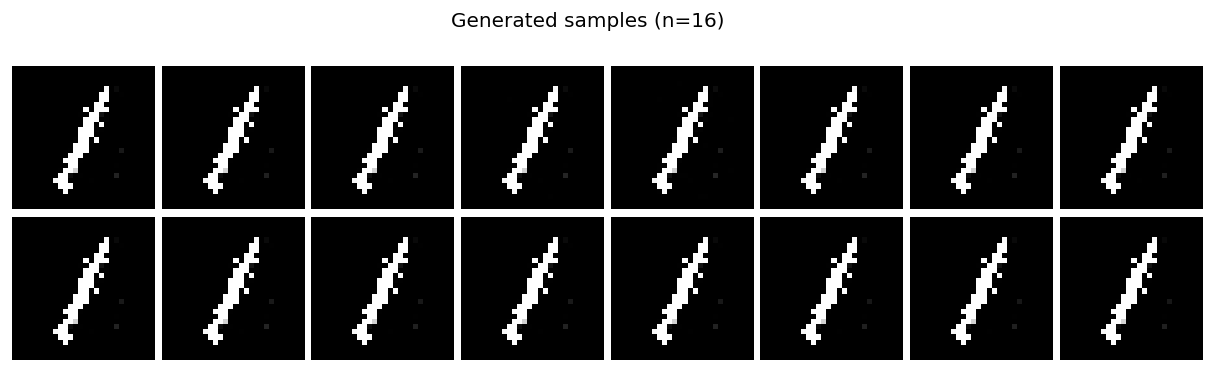


=== Nearest real training image per generated sample (memorization check) ===
Sample 1: nearest-neighbor L2 distance = 14.0062
Sample 2: nearest-neighbor L2 distance = 14.0296
Sample 3: nearest-neighbor L2 distance = 13.9670
Sample 4: nearest-neighbor L2 distance = 13.9527
Sample 5: nearest-neighbor L2 distance = 13.8829
Sample 6: nearest-neighbor L2 distance = 13.9688


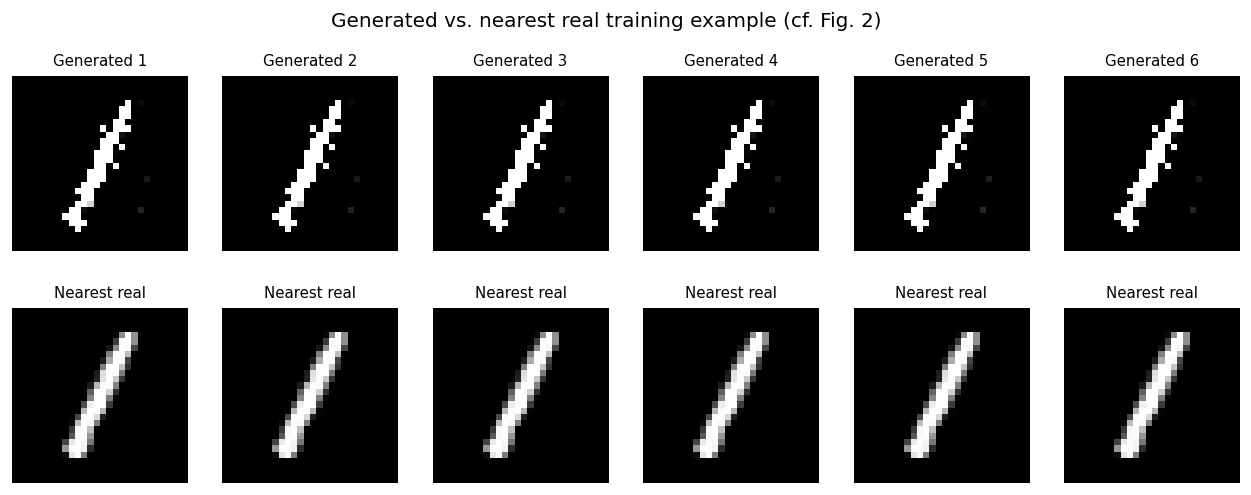


=== Latent-space interpolation (cf. Fig. 3) ===


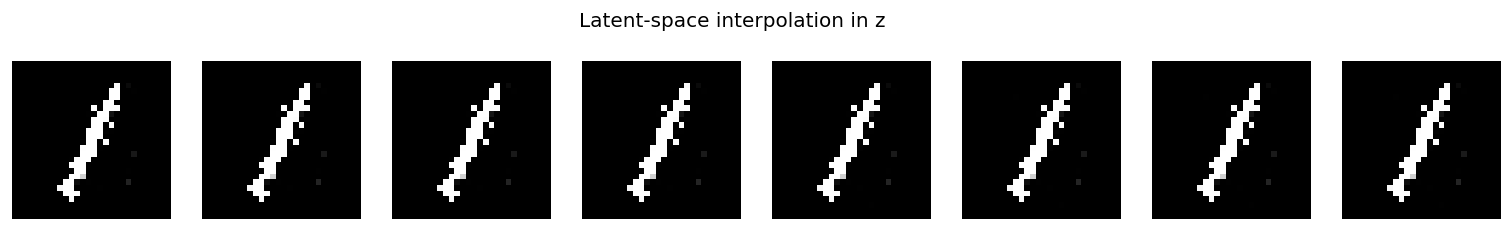

In [12]:
# ============================================================================
# 5. PREDICTION GENERATION PIPELINE
#    A single reusable entry point for sampling new images from the trained
#    Generator and rendering them. Wraps the building blocks already used in
#    Section 4 (Fig. 2 nearest-neighbor check, Fig. 3 latent interpolation)
#    into standalone functions, plus a grid-sampling utility for viewing
#    many generations at once. Everything renders through an in-memory PNG
#    buffer (BytesIO) + IPython display, consistent with the imports set up
#    in Section 0 — no plt.show() calls, so this works headless too.
# ============================================================================

def generate_images(n_samples=16, z=None, seed=None):
    """
    Sample n_samples new images from the trained Generator G.
    Pass an explicit `z` [n_samples, Z_DIM] to control the latent codes
    (e.g. for reproducing a specific sample or feeding in an interpolation),
    or a `seed` for reproducible random sampling; otherwise draws fresh noise.
    Returns: (images [n_samples, IMG_DIM] in [0,1] as numpy, z used as numpy)
    """
    G.eval()
    with torch.no_grad():
        if z is None:
            if seed is not None:
                gen = torch.Generator(device=DEVICE).manual_seed(seed)
                z = torch.randn(n_samples, Z_DIM, device=DEVICE, generator=gen)
            else:
                z = torch.randn(n_samples, Z_DIM, device=DEVICE)
        else:
            z = z.to(DEVICE)
            n_samples = z.shape[0]
        imgs = G(z).cpu().numpy()
    return imgs, z.cpu().numpy()


def render_grid(images, n_cols=8, title="Generated samples", figsize_scale=1.6):
    """
    Arrange a batch of flattened [IMG_DIM] images into an n_cols-wide grid
    (GridSpec), render to an in-memory PNG, and display inline.
    """
    n = images.shape[0]
    n_rows = math.ceil(n / n_cols)

    fig = plt.figure(figsize=(figsize_scale * n_cols, figsize_scale * n_rows), facecolor="white")
    gs = GridSpec(n_rows, n_cols, figure=fig, wspace=0.05, hspace=0.05)

    for i in range(n):
        ax = fig.add_subplot(gs[i // n_cols, i % n_cols])
        ax.imshow(images[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")

    fig.suptitle(title, color="black", y=1.02)

    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    plt.close(fig)
    buf.seek(0)
    display(IPImage(data=buf.read()))


def nearest_real_matches(images):
    """
    For each generated image, find its nearest real training image (L2 in
    pixel space) — the memorization check from Fig. 2, factored out for reuse.
    Returns: (matches [n, IMG_DIM], distances [n])
    """
    train_imgs_all = train_dataset.images  # [N, IMG_DIM]
    matches, dists = [], []
    for g_img in images:
        d = np.sum((train_imgs_all - g_img[None, :]) ** 2, axis=1)
        idx = np.argmin(d)
        matches.append(train_imgs_all[idx])
        dists.append(d[idx])
    return np.stack(matches), np.array(dists)


def interpolate_latent(z_a=None, z_b=None, n_steps=8, seed=None):
    """
    Linear interpolation between two latent points, decoded through G
    (Fig. 3 analogue). Draws random endpoints if not supplied.
    Returns: images [n_steps, IMG_SIZE, IMG_SIZE]
    """
    G.eval()
    gen = torch.Generator(device=DEVICE).manual_seed(seed) if seed is not None else None
    if z_a is None:
        z_a = torch.randn(1, Z_DIM, device=DEVICE, generator=gen)
    if z_b is None:
        z_b = torch.randn(1, Z_DIM, device=DEVICE, generator=gen)

    alphas = np.linspace(0, 1, n_steps)
    imgs = []
    with torch.no_grad():
        for a in alphas:
            z_interp = (1 - a) * z_a + a * z_b
            imgs.append(G(z_interp).cpu().numpy().reshape(IMG_SIZE, IMG_SIZE))
    return np.stack(imgs)


def _display_fig(fig):
    """Small helper: render a matplotlib fig to inline PNG via buffer + close it."""
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    plt.close(fig)
    buf.seek(0)
    display(IPImage(data=buf.read()))


def run_prediction_pipeline(n_samples=16, n_cols=8, show_nearest=True,
                             show_interpolation=True, n_interp=8, seed=None):
    """
    End-to-end prediction pipeline — the single call to go from a trained G
    to a full qualitative report:
      1. Generate n_samples new images from noise, display as a grid
      2. (optional) Nearest-real-neighbor comparison (memorization check)
      3. (optional) Latent-interpolation strip between two random z points
    Returns the generated images and the z codes used to produce them.
    """
    print(f"\n=== Generating {n_samples} new samples from G ===")
    imgs, z_used = generate_images(n_samples=n_samples, seed=seed)
    render_grid(imgs, n_cols=n_cols, title=f"Generated samples (n={n_samples})")

    if show_nearest:
        print("\n=== Nearest real training image per generated sample (memorization check) ===")
        k = min(6, n_samples)  # keep the side-by-side comparison readable
        matches, dists = nearest_real_matches(imgs[:k])
        for i in range(k):
            print(f"Sample {i+1}: nearest-neighbor L2 distance = {dists[i]:.4f}")

        fig, axes = plt.subplots(2, k, figsize=(2.2 * k, 4.6), facecolor="white")
        for i in range(k):
            axes[0, i].imshow(imgs[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray", vmin=0, vmax=1)
            axes[0, i].set_title(f"Generated {i+1}", color="black", fontsize=9)
            axes[0, i].axis("off")
            axes[1, i].imshow(matches[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray", vmin=0, vmax=1)
            axes[1, i].set_title("Nearest real", color="black", fontsize=9)
            axes[1, i].axis("off")
        fig.suptitle("Generated vs. nearest real training example (cf. Fig. 2)", color="black")
        _display_fig(fig)

    if show_interpolation:
        print("\n=== Latent-space interpolation (cf. Fig. 3) ===")
        interp_imgs = interpolate_latent(n_steps=n_interp, seed=seed)
        fig, axes = plt.subplots(1, n_interp, figsize=(2 * n_interp, 2.2), facecolor="white")
        for i, img in enumerate(interp_imgs):
            axes[i].imshow(img, cmap="gray", vmin=0, vmax=1)
            axes[i].axis("off")
        fig.suptitle("Latent-space interpolation in z", color="black")
        _display_fig(fig)

    return imgs, z_used


# ---- Run it -------------------------------------------------------------
generated_images, latent_codes = run_prediction_pipeline(
    n_samples=16, n_cols=8, seed=SEED
)

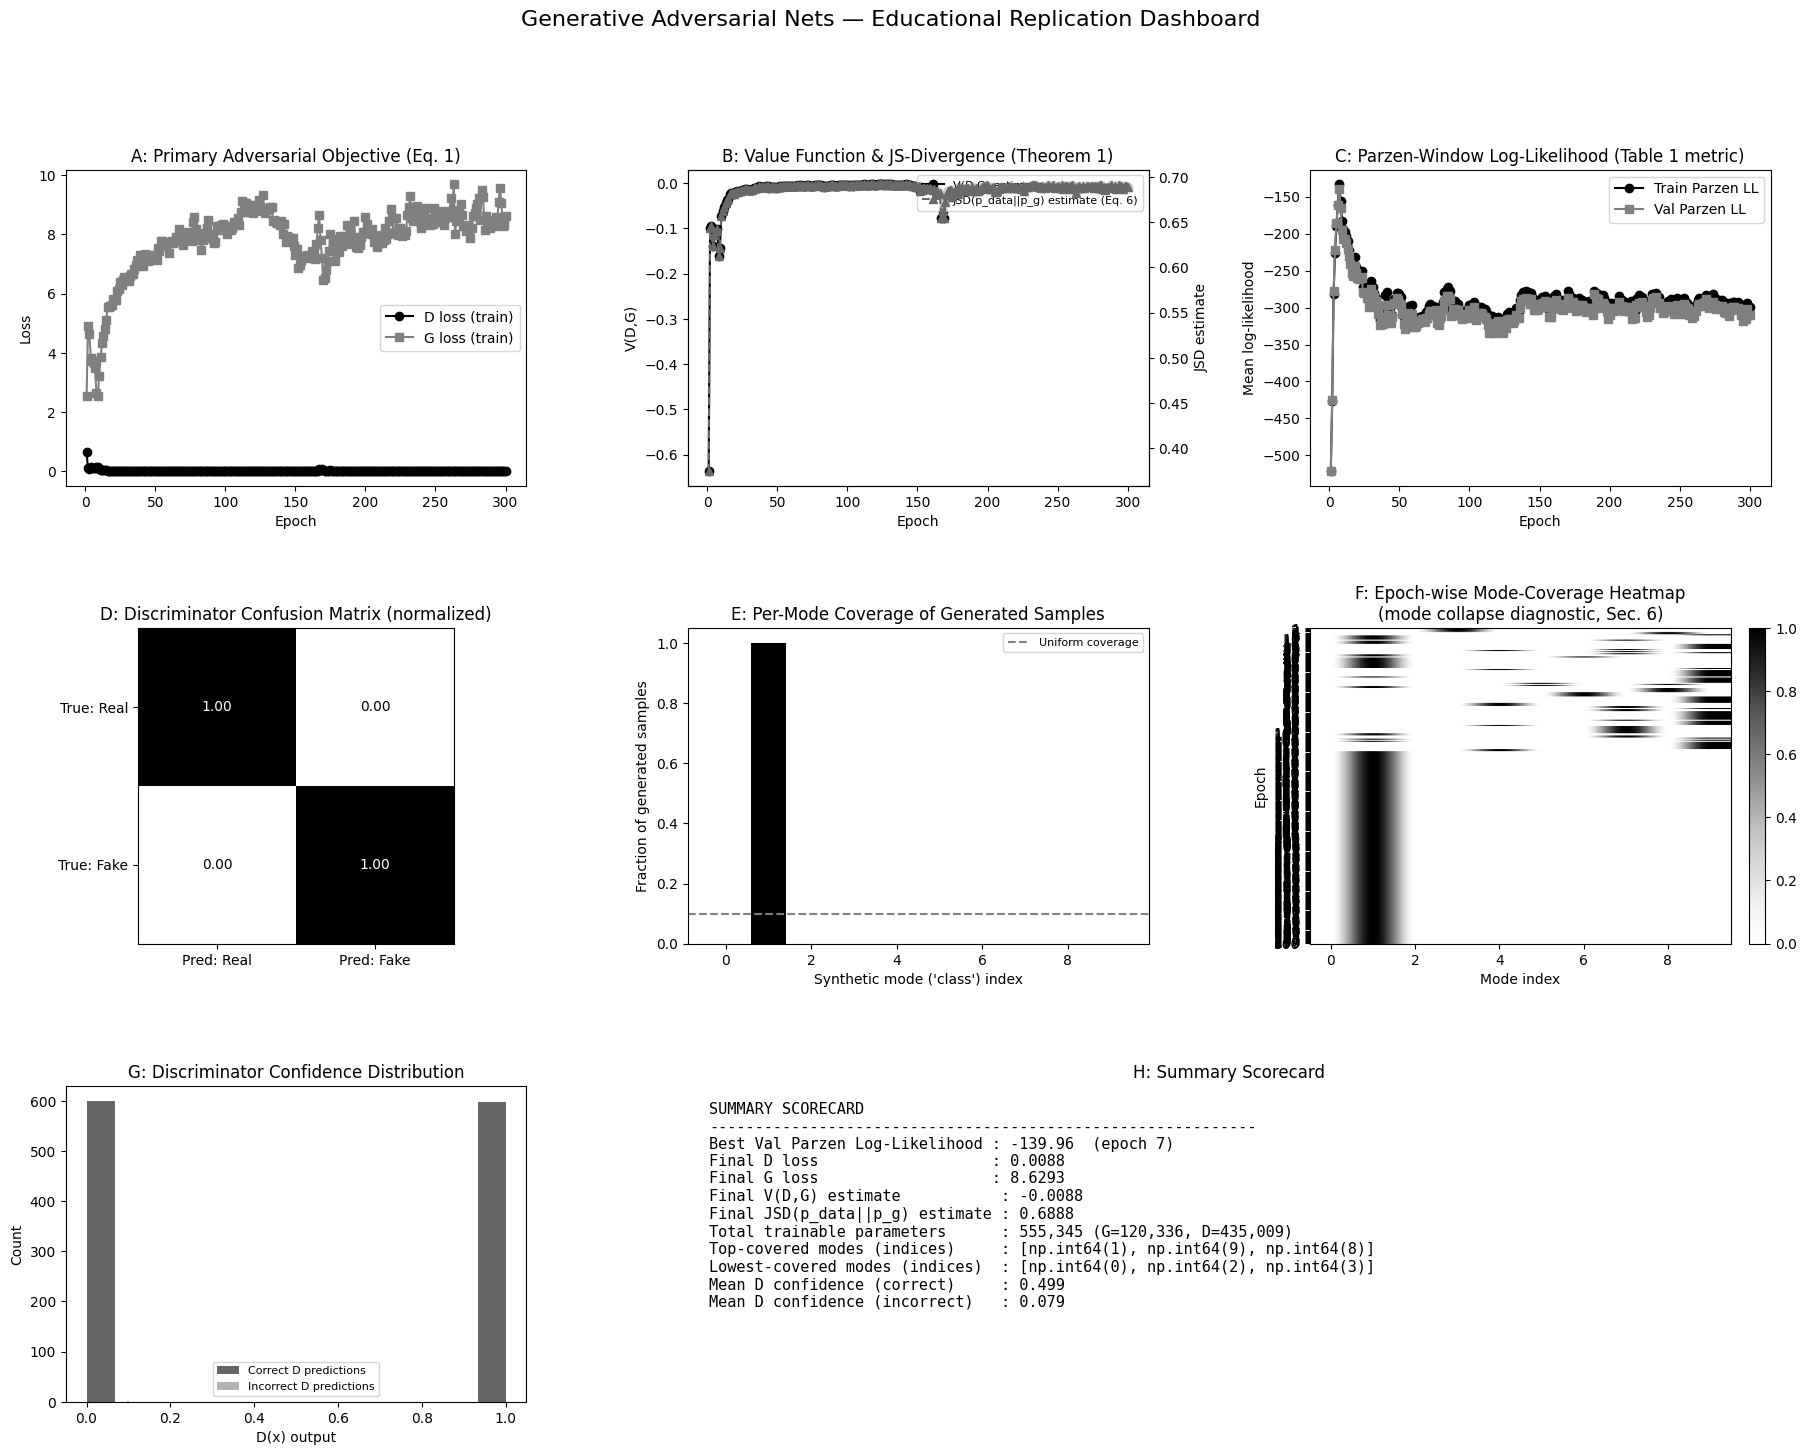

In [13]:
# ============================================================================
# 5. FINAL MULTI-PANEL SUMMARY DASHBOARD (Panels A-H)
# ============================================================================

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "legend.labelcolor": "black",
})

epochs_range = list(range(1, EPOCHS + 1))

fig = plt.figure(figsize=(22, 16), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ---- Panel A: total training objective (D_loss and G_loss) -----------------
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["d_loss"], marker="o", color="black", label="D loss (train)")
axA.plot(epochs_range, history["g_loss"], marker="s", color="gray", label="G loss (train)")
axA.set_title("A: Primary Adversarial Objective (Eq. 1)", color="black")
axA.set_xlabel("Epoch"); axA.set_ylabel("Loss")
axA.legend()
axA.tick_params(colors="black")

# ---- Panel B: decomposed loss components (V value & JSD estimate) ---------
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, history["v_value"], marker="o", color="black", label="V(D,G) estimate")
axB2 = axB.twinx()
axB2.plot(epochs_range, history["jsd_estimate"], marker="^", color="dimgray",
          linestyle="--", label="JSD(p_data||p_g) estimate (Eq. 6)")
axB.set_title("B: Value Function & JS-Divergence (Theorem 1)", color="black")
axB.set_xlabel("Epoch"); axB.set_ylabel("V(D,G)", color="black")
axB2.set_ylabel("JSD estimate", color="black")
axB2.tick_params(colors="black")
axB.tick_params(colors="black")
lines1, labels1 = axB.get_legend_handles_labels()
lines2, labels2 = axB2.get_legend_handles_labels()
axB.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

# ---- Panel C: paper's actual evaluation metric (Parzen log-likelihood) ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_parzen_ll"], marker="o", color="black", label="Train Parzen LL")
axC.plot(epochs_range, history["val_parzen_ll"], marker="s", color="gray", label="Val Parzen LL")
axC.set_title("C: Parzen-Window Log-Likelihood (Table 1 metric)", color="black")
axC.set_xlabel("Epoch"); axC.set_ylabel("Mean log-likelihood")
axC.legend()
axC.tick_params(colors="black")

# ---- Panel D: Discriminator confusion matrix (real=1 vs fake=0) -----------
# Note: a standard multi-class confusion matrix does not apply to this
# unsupervised generative task. The paper-appropriate analogue is D's own
# binary real-vs-fake classification confusion matrix, since D truly is a
# binary classifier by construction (Sec. 3).
axD = fig.add_subplot(gs[1, 0])
axD.set_facecolor("white")
with torch.no_grad():
    real_batch = torch.stack([val_dataset[i][0] for i in range(len(val_dataset))]).to(DEVICE)
    z_batch = torch.randn(len(val_dataset), Z_DIM, device=DEVICE)
    fake_batch = G(z_batch)
    d_real_out = D(real_batch).cpu().numpy()
    d_fake_out = D(fake_batch).cpu().numpy()

pred_real = (d_real_out >= 0.5).astype(int)   # 1 = predicted real
pred_fake = (d_fake_out >= 0.5).astype(int)

tp = np.sum(pred_real == 1)   # real correctly called real
fn = np.sum(pred_real == 0)   # real incorrectly called fake
fp = np.sum(pred_fake == 1)   # fake incorrectly called real
tn = np.sum(pred_fake == 0)   # fake correctly called fake

cm = np.array([[tp, fn], [fp, tn]], dtype=float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

im = axD.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1)
axD.set_xticks([0, 1]); axD.set_yticks([0, 1])
axD.set_xticklabels(["Pred: Real", "Pred: Fake"], color="black")
axD.set_yticklabels(["True: Real", "True: Fake"], color="black")
for i in range(2):
    for j in range(2):
        axD.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                  color="white" if cm_norm[i, j] > 0.5 else "black")
axD.set_title("D: Discriminator Confusion Matrix (normalized)", color="black")

# ---- Panel E: per-mode ("class") coverage bar chart, final epoch ----------
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
final_coverage = history["mode_coverage_per_epoch"][-1]
axE.bar(range(NUM_MODES), final_coverage, color="black")
axE.axhline(1.0 / NUM_MODES, color="gray", linestyle="--", label="Uniform coverage")
axE.set_title("E: Per-Mode Coverage of Generated Samples", color="black")
axE.set_xlabel("Synthetic mode ('class') index"); axE.set_ylabel("Fraction of generated samples")
axE.legend(fontsize=8)

# ---- Panel F: epoch-wise per-mode coverage heatmap -------------------------
axF = fig.add_subplot(gs[1, 2])
axF.set_facecolor("white")
coverage_matrix = np.stack(history["mode_coverage_per_epoch"], axis=0)  # [epochs, modes]
im2 = axF.imshow(coverage_matrix, cmap="Greys", aspect="auto")
axF.set_xlabel("Mode index"); axF.set_ylabel("Epoch")
axF.set_yticks(range(EPOCHS)); axF.set_yticklabels(epochs_range)
axF.set_title("F: Epoch-wise Mode-Coverage Heatmap\n(mode collapse diagnostic, Sec. 6)", color="black")
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
cbar2.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar2.ax.get_yticklabels(), color="black")

# ---- Panel G: D's confidence distribution, correct vs incorrect -----------
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
correct_conf = np.concatenate([d_real_out[pred_real == 1], d_fake_out[pred_fake == 0]])
incorrect_conf = np.concatenate([d_real_out[pred_real == 0], d_fake_out[pred_fake == 1]])
axG.hist(correct_conf, bins=15, alpha=0.6, color="black", label="Correct D predictions")
axG.hist(incorrect_conf, bins=15, alpha=0.6, color="gray", label="Incorrect D predictions")
axG.set_title("G: Discriminator Confidence Distribution", color="black")
axG.set_xlabel("D(x) output"); axG.set_ylabel("Count")
axG.legend(fontsize=8)

# ---- Panel H: text-based summary scorecard ---------------------------------
axH = fig.add_subplot(gs[2, 1:3])
axH.set_facecolor("white")
axH.axis("off")

best_val_idx = int(np.argmax(history["val_parzen_ll"]))
best_val_ll = history["val_parzen_ll"][best_val_idx]
best_epoch = best_val_idx + 1
top_modes = np.argsort(final_coverage)[::-1][:3]
low_modes = np.argsort(final_coverage)[:3]
mean_conf_correct = correct_conf.mean() if len(correct_conf) > 0 else float("nan")
mean_conf_incorrect = incorrect_conf.mean() if len(incorrect_conf) > 0 else float("nan")

scorecard_text = (
    f"SUMMARY SCORECARD\n"
    f"------------------------------------------------------------\n"
    f"Best Val Parzen Log-Likelihood : {best_val_ll:.2f}  (epoch {best_epoch})\n"
    f"Final D loss                   : {history['d_loss'][-1]:.4f}\n"
    f"Final G loss                   : {history['g_loss'][-1]:.4f}\n"
    f"Final V(D,G) estimate           : {history['v_value'][-1]:.4f}\n"
    f"Final JSD(p_data||p_g) estimate : {history['jsd_estimate'][-1]:.4f}\n"
    f"Total trainable parameters      : {TOTAL_PARAMS:,} (G={n_params_G:,}, D={n_params_D:,})\n"
    f"Top-covered modes (indices)     : {list(top_modes)}\n"
    f"Lowest-covered modes (indices)  : {list(low_modes)}\n"
    f"Mean D confidence (correct)     : {mean_conf_correct:.3f}\n"
    f"Mean D confidence (incorrect)   : {mean_conf_incorrect:.3f}\n"
)
axH.text(0.02, 0.95, scorecard_text, va="top", ha="left", fontsize=11,
          color="black", family="monospace")
axH.set_title("H: Summary Scorecard", color="black")

fig.suptitle("Generative Adversarial Nets — Educational Replication Dashboard",
             fontsize=16, color="black")

# ---- Render to in-memory buffer and display (no plt.savefig / plt.show) ---
buf = BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))